# Install dan import Liblary

In [ ]:
! pip install keras-tuner --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 12.8 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, BatchNormalization, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2

import keras_tuner as kt

from tensorflow.keras.metrics import RootMeanSquaredError
from keras_tuner import RandomSearch

In [ ]:
import random
import os
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)
os.environ['PYTHONHASHSEED'] = str(42)

# Import Data

In [ ]:
df_data = pd.read_csv("/content/data_TLKM_data1.csv", index_col=0)
df_data.index = pd.to_datetime(df_data.index)

In [ ]:
print(type(df_data.index))

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


# Feature Engineering Data

In [ ]:
df_data['return'] = df_data['close'].pct_change().shift(1)
df_data['volatility'] = df_data['return'].rolling(window=5).std()
df_data['ma'] = df_data['close'].shift(1).rolling(window=10).mean()

df_data = df_data.dropna()

features = ['open', 'high', 'low', 'volume', 'return', 'volatility', 'ma']
X = df_data[features].values
y = df_data[['close']].values.reshape(-1, 1)

In [ ]:
df_data.head()
df_data.corr()

,open,high,low,close,volume,return,volatility,ma
open,1.000000,0.999188,0.999297,0.998612,0.015488,0.014932,-0.167632,0.995661
high,0.999188,1.000000,0.998990,0.999342,0.026365,0.011595,-0.159780,0.995639
low,0.999297,0.998990,1.000000,0.999289,0.005358,0.013760,-0.174036,0.995220
close,0.998612,0.999342,0.999289,1.000000,0.015911,0.011970,-0.168122,0.994837
volume,0.015488,0.026365,0.005358,0.015911,1.000000,-0.036438,0.215056,0.023344
return,0.014932,0.011595,0.013760,0.011970,-0.036438,1.000000,0.059813,-0.029289
volatility,-0.167632,-0.159780,-0.174036,-0.168122,0.215056,0.059813,1.000000,-0.168232
ma,0.995661,0.995639,0.995220,0.994837,0.023344,-0.029289,-0.168232,1.000000


# Split Data
*Train 80%, validasi 10%, testing 10%*

In [ ]:
train_size = int(len(X) * 0.8)
val_size = int(len(X) * 0.1)
test_size = len(X) - train_size - val_size

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size + val_size], y[train_size:train_size + val_size]
X_test, y_test = X[train_size + val_size:], y[train_size + val_size:]

In [ ]:
print(f"Total data: {len(y)}")
print(f"Training data: {len(y_train)} ({len(y_train)/len(y)*100:.2f}%)")
print(f"Validation data: {len(y_val)} ({len(y_val)/len(y)*100:.2f}%)")
print(f"Test data: {len(y_test)} ({len(y_test)/len(y)*100:.2f}%)")

Total data: 3444
Training data: 2755 (79.99%)
Validation data: 344 (9.99%)
Test data: 345 (10.02%)


In [ ]:
import numpy as np

def has_overlap(a, b):
    a_str = set(map(lambda x: x.tobytes(), a))
    b_str = set(map(lambda x: x.tobytes(), b))
    return len(a_str & b_str) > 0

print("Train ↔ Val Overlap:", has_overlap(X_train, X_val))
print("Train ↔ Test Overlap:", has_overlap(X_train, X_test))
print("Val ↔ Test Overlap:", has_overlap(X_val, X_test))

Train ↔ Val Overlap: False
Train ↔ Test Overlap: False
Val ↔ Test Overlap: False


# MinmaxScaler/Scale Data

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler_x = MinMaxScaler(feature_range=(-1, 1))
scaler_y = MinMaxScaler(feature_range=(-1, 1))

X_train_scaled = scaler_x.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train)

X_val_scaled = scaler_x.transform(X_val)
y_val_scaled = scaler_y.transform(y_val)

X_test_scaled = scaler_x.transform(X_test)
y_test_scaled = scaler_y.transform(y_test)

*Simpan Hasil Scaler*

In [ ]:
import joblib

# Simpan kedua scaler
joblib.dump(scaler_x, 'scaler_x.pkl')
joblib.dump(scaler_y, 'scaler_y.pkl')

['scaler_y.pkl']

# Buat Windowing Data 90 Hari

In [ ]:
def create_windows(data, target, window_size):
    X_windows, y_windows = [], []
    for i in range(len(data) - window_size):
        X_windows.append(data[i:i + window_size])
        y_windows.append(target[i + window_size])
    return np.array(X_windows), np.array(y_windows)

window_size = 30

X_train_windows, y_train_windows = create_windows(X_train_scaled, y_train_scaled, window_size)
X_val_windows, y_val_windows = create_windows(X_val_scaled, y_val_scaled, window_size)
X_test_windows, y_test_windows = create_windows(X_test_scaled, y_test_scaled, window_size)

print(f"X_train_windows shape: {X_train_windows.shape}")
print(f"y_train_windows shape: {y_train_windows.shape}")
print(f"X_val_windows shape: {X_val_windows.shape}")
print(f"y_val_windows shape: {y_val_windows.shape}")
print(f"X_test_windows shape: {X_test_windows.shape}")
print(f"y_test_windows shape: {y_test_windows.shape}")

X_train_windows shape: (2725, 30, 7)
y_train_windows shape: (2725, 1)
X_val_windows shape: (314, 30, 7)
y_val_windows shape: (314, 1)
X_test_windows shape: (315, 30, 7)
y_test_windows shape: (315, 1)


# Arsitektur Model *LSTM*
*Menggunakan Bidirectioanl LSTM* dan
*Tuning Hyperparameter*

In [ ]:
def build_model(hp):

    lstm_1 = hp.Choice("lstm_1", values=[128, 160, 192])
    dense_unit = hp.Choice("dense_unit", values=[128, 160, 192])
    dropout_rate = hp.Choice("dropout_rate", values=[0.02, 0.05, 0.1, 0.2, 0.3])
    learning_rate = hp.Choice("learning_rate", values=[1e-4, 5e-4, 1e-3, 2e-3, 5e-3])

    model = Sequential([
        Input(shape=(window_size, X_train_windows.shape[2])),
        Bidirectional(LSTM(lstm_1, return_sequences=False)),
        Dropout(dropout_rate),
        Dense(dense_unit, activation='relu'),
        Dense(1),
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='mean_squared_error',
        metrics=['mae', RootMeanSquaredError()]
    )
    return model

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
]

In [ ]:
batch_sizes = [16, 32, 64]
best_val_losses = []
best_models = []
all_results = []

for bs in batch_sizes:
    print(f"Tuning dengan batch_size = {bs}")

    tuner = RandomSearch(
        build_model,
        objective='val_loss',
        max_trials=10,
        executions_per_trial=1,
        directory='tuner_result',
        project_name=f'lstm_tuning_bs_{bs}'
    )

    tuner.search(X_train_windows, y_train_windows,
                 epochs=50,
                 validation_data=(X_val_windows, y_val_windows),
                 callbacks=callbacks,
                 batch_size=bs, shuffle=False)

    best_hp = tuner.get_best_hyperparameters(1)[0]
    val_loss = tuner.oracle.get_best_trials(1)[0].metrics.get_last_value('val_loss')

    best_models.append((bs, best_hp))
    best_val_losses.append(val_loss)

    trials = tuner.oracle.trials.values()
    for trial in trials:
        hps = trial.hyperparameters.values
        all_results.append({
            'batch_size': bs,
            'val_loss': trial.metrics.get_last_value('val_loss'),
            'lstm_1': hps['lstm_1'],
            'dense_unit': hps['dense_unit'],
            'dropout_rate': hps['dropout_rate'],
            'learning_rate': hps['learning_rate'],
        })

# Ambil model terbaik
best_idx = best_val_losses.index(min(best_val_losses))
best_batch_size, best_hp = best_models[best_idx]

print(f"\nBatch size terbaik: {best_batch_size}")
print("Best hyperparameters:")
print(best_hp.values)

Trial 10 Complete [00h 00m 19s]
val_loss: 0.0022801256272941828

Best val_loss So Far: 0.002074027433991432
Total elapsed time: 00h 04m 44s

Batch size terbaik: 16
Best hyperparameters:
{'lstm_1': 192, 'dense_unit': 160, 'dropout_rate': 0.2, 'learning_rate': 0.005}


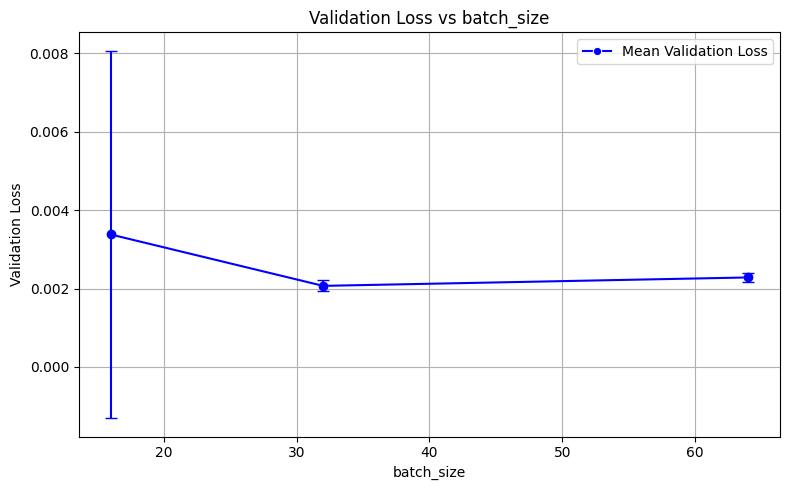

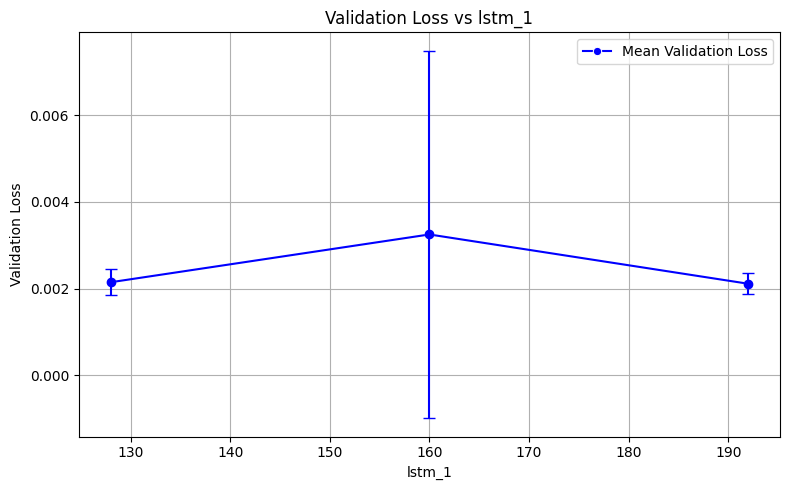

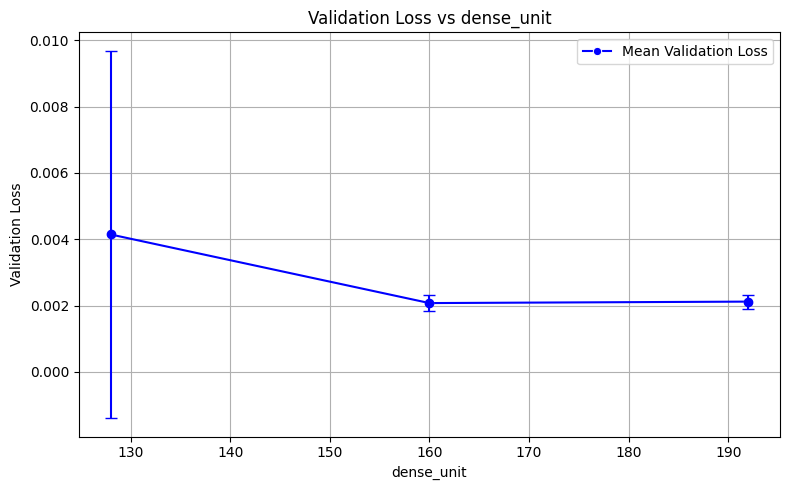

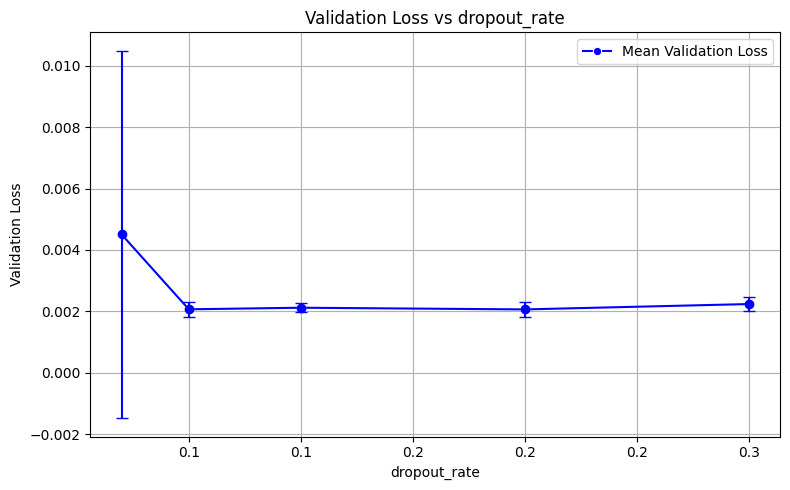

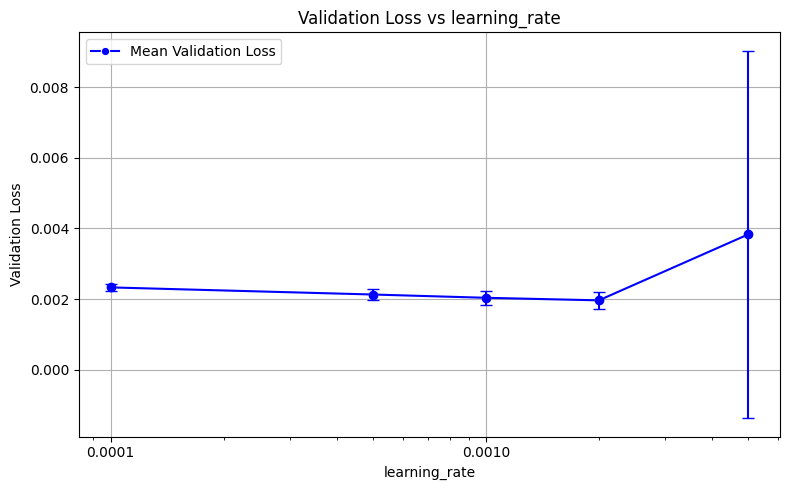

In [ ]:
from matplotlib.ticker import FuncFormatter, ScalarFormatter
import numpy as np
import seaborn as sns

results_df = pd.DataFrame(all_results)
hyperparams = ['batch_size', 'lstm_1', 'dense_unit', 'dropout_rate', 'learning_rate']

for hp in hyperparams:
    plt.figure(figsize=(8, 5))

    grouped = results_df.groupby(hp)['val_loss'].agg(['mean', 'std']).reset_index()
    grouped = grouped.sort_values(by=hp)

    sns.lineplot(
        x=hp,
        y='mean',
        data=grouped,
        marker='o',
        label='Mean Validation Loss',
        color='blue'
    )

    plt.errorbar(
        grouped[hp],
        grouped['mean'],
        yerr=grouped['std'],
        fmt='o',
        color='blue',
        capsize=4
    )

    ax = plt.gca()
    if hp == 'learning_rate':
        ax.set_xscale('log')
        ax.xaxis.set_major_formatter(ScalarFormatter())
        ax.ticklabel_format(style='plain', axis='x')
    elif results_df[hp].dtype == float:
        formatter = FuncFormatter(lambda x, _: f'{x:.1f}' if x < 1 else f'{x:.0f}')
        ax.xaxis.set_major_formatter(formatter)

    plt.title(f'Validation Loss vs {hp}')
    plt.xlabel(hp)
    plt.ylabel('Validation Loss')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
results_table = results_df.copy()
results_table = results_table.rename(columns={
    'dropout_rate': 'dropout',
    'batch_size': 'batch size',
    'learning_rate': 'learning rate',
    'lstm_1': 'unit lstm',
    'dense_unit': 'unit dense',
    'val_loss': 'loss'
})

results_table.insert(0, 'no', range(1, len(results_table) + 1))

results_table = results_table[['no', 'dropout', 'batch size', 'learning rate', 'unit lstm', 'unit dense', 'loss']]

best_idx = results_table['loss'].idxmin()

output_lines = []
for i, row in results_table.iterrows():
    line = f"{row['no']:>2} | {row['dropout']:<7} | {row['batch size']:<10} | {row['learning rate']:<14} | {row['unit lstm']:<9} | {row['unit dense']:<10} | {row['loss']:<.6f}"
    if i == best_idx:
        line += "  <= BEST"
    output_lines.append(line)

header = "no | dropout | batch size | learning rate | unit lstm | unit dense | loss"
print(header)
print("-" * len(header))
for line in output_lines:
    print(line)


no | dropout | batch size | learning rate | unit lstm | unit dense | loss
-------------------------------------------------------------------------
1.0 | 0.05    | 16.0       | 0.002          | 192.0     | 192.0      | 0.001734
2.0 | 0.1     | 16.0       | 0.001          | 160.0     | 160.0      | 0.001884
3.0 | 0.2     | 16.0       | 0.0005         | 192.0     | 160.0      | 0.001969
4.0 | 0.02    | 16.0       | 0.005          | 160.0     | 128.0      | 0.016701
5.0 | 0.05    | 16.0       | 0.001          | 160.0     | 128.0      | 0.001829
6.0 | 0.02    | 16.0       | 0.005          | 128.0     | 192.0      | 0.001716
7.0 | 0.05    | 16.0       | 0.0001         | 128.0     | 192.0      | 0.002296
8.0 | 0.05    | 16.0       | 0.005          | 128.0     | 128.0      | 0.001728
9.0 | 0.2     | 16.0       | 0.005          | 192.0     | 160.0      | 0.001700  <= BEST
10.0 | 0.05    | 16.0       | 0.0001         | 192.0     | 192.0      | 0.002230
11.0 | 0.02    | 32.0       | 0.001       

In [ ]:
# Bangun ulang dan latih ulang hanya 1 model terbaik
final_model = build_model(best_hp)

In [ ]:
history = final_model.fit(X_train_windows, y_train_windows,
                validation_data=(X_val_windows, y_val_windows),
                epochs=100,
                batch_size=best_batch_size,
                callbacks=callbacks, shuffle=False)

Epoch 1/100
171/171 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.1871 - mae: 0.2259 - root_mean_squared_error: 0.3766 - val_loss: 0.4550 - val_mae: 0.6669 - val_root_mean_squared_error: 0.6745 - learning_rate: 0.0050
Epoch 2/100
171/171 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0539 - mae: 0.1464 - root_mean_squared_error: 0.2084 - val_loss: 0.0051 - val_mae: 0.0590 - val_root_mean_squared_error: 0.0713 - learning_rate: 0.0050
Epoch 3/100
171/171 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0638 - mae: 0.1666 - root_mean_squared_error: 0.2285 - val_loss: 0.0073 - val_mae: 0.0725 - val_root_mean_squared_error: 0.0856 - learning_rate: 0.0050
Epoch 4/100
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0305 - mae: 0.1249 - root_mean_squared_error: 0.1624 - val_loss: 0.0043 - val_mae: 0.0528 - val_root_mean_squared_error: 0.0656 - learning_rate: 0.0050
Epoch 5/100
171/171 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0289 - mae: 0.1196 - root_mean_squared_error: 0.1572 - val_loss: 0.0053 - v

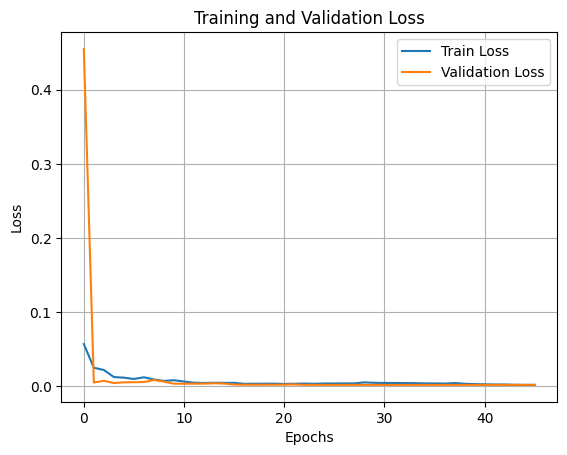

In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

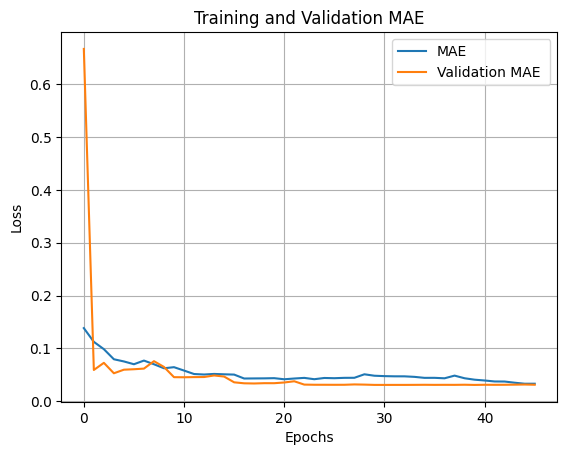

In [ ]:
plt.plot(history.history['mae'], label='MAE')
plt.plot(history.history['val_mae'], label='Validation MAE ')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation MAE')
plt.legend()
plt.grid(True)
plt.show()

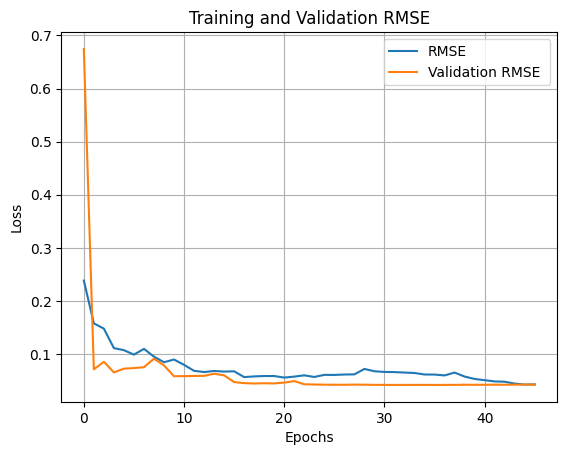

In [ ]:
plt.plot(history.history['root_mean_squared_error'], label='RMSE')
plt.plot(history.history['val_root_mean_squared_error'], label='Validation RMSE ')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation RMSE')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
date_array = df_data.index[-len(y):]

date_array_for_validation = date_array[train_size:train_size + val_size][window_size:]
date_array_for_testing = date_array[train_size + val_size:][window_size:]

# Visualisasi & Evaluasi
**RMSE, MAPE dan R-Square**

In [ ]:
val_loss = final_model.evaluate(X_val_windows, y_val_windows, verbose=0)

y_val_pred = final_model.predict(X_val_windows)
y_val_rescaled = scaler_y.inverse_transform(y_val_windows.reshape(-1, 1))
y_val_pred_rescaled = scaler_y.inverse_transform(y_val_pred.reshape(-1, 1))

rmse_val = np.sqrt(mean_squared_error(y_val_rescaled, y_val_pred_rescaled))
mape_val = mean_absolute_percentage_error(y_val_rescaled, y_val_pred_rescaled) * 100
r2_val = r2_score(y_val_rescaled, y_val_pred_rescaled)

print("Validation Loss (MSE):", val_loss)
print("Validation RMSE:", rmse_val)
print("Validation MAPE:", f"{mape_val:.2f}%")
print("Validation R-Squared:", r2_val)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Validation Loss (MSE): [0.0017617377452552319, 0.030829226598143578, 0.0419730581343174]
Validation RMSE: 73.03312725872628
Validation MAPE: 1.29%
Validation R-Squared: 0.9254789697352847


In [ ]:
print("\nContoh hasil prediksi (rescaled):\n", y_val_pred_rescaled[:5])
print("\nContoh nilai aktual (rescaled):\n", y_val_rescaled[:5])


Contoh hasil prediksi (rescaled):
 [[4527.7354]
 [4511.3774]
 [4497.884 ]
 [4443.9175]
 [4481.4097]]

Contoh nilai aktual (rescaled):
 [[4540.]
 [4520.]
 [4430.]
 [4540.]
 [4580.]]


In [ ]:
val_dates = date_array_for_validation[-len(y_val_rescaled):]

df_val_prediksi = pd.DataFrame({
    'date': val_dates[:40],
    'actual': y_val_rescaled[:40].flatten(),
    'prediksi': y_val_pred_rescaled[:40].flatten()
})

df_val_prediksi['selisih'] = df_val_prediksi['actual'] - df_val_prediksi['prediksi']
print(df_val_prediksi)

         date  actual     prediksi     selisih
0  2022-04-04  4540.0  4527.735352   12.264648
1  2022-04-05  4520.0  4511.377441    8.622559
2  2022-04-06  4430.0  4497.883789  -67.883789
3  2022-04-07  4540.0  4443.917480   96.082520
4  2022-04-08  4580.0  4481.409668   98.590332
5  2022-04-11  4590.0  4584.582031    5.417969
6  2022-04-12  4630.0  4568.871582   61.128418
7  2022-04-13  4690.0  4593.849609   96.150391
8  2022-04-14  4680.0  4688.655762   -8.655762
9  2022-04-18  4710.0  4660.233887   49.766113
10 2022-04-19  4680.0  4683.997070   -3.997070
11 2022-04-20  4630.0  4668.860352  -38.860352
12 2022-04-21  4620.0  4626.472656   -6.472656
13 2022-04-22  4620.0  4625.948242   -5.948242
14 2022-04-25  4710.0  4621.989258   88.010742
15 2022-04-26  4760.0  4625.178711  134.821289
16 2022-04-27  4770.0  4693.465820   76.534180
17 2022-04-28  4620.0  4745.327637 -125.327637
18 2022-05-09  4310.0  4754.302246 -444.302246
19 2022-05-10  4340.0  4448.506348 -108.506348
20 2022-05-11

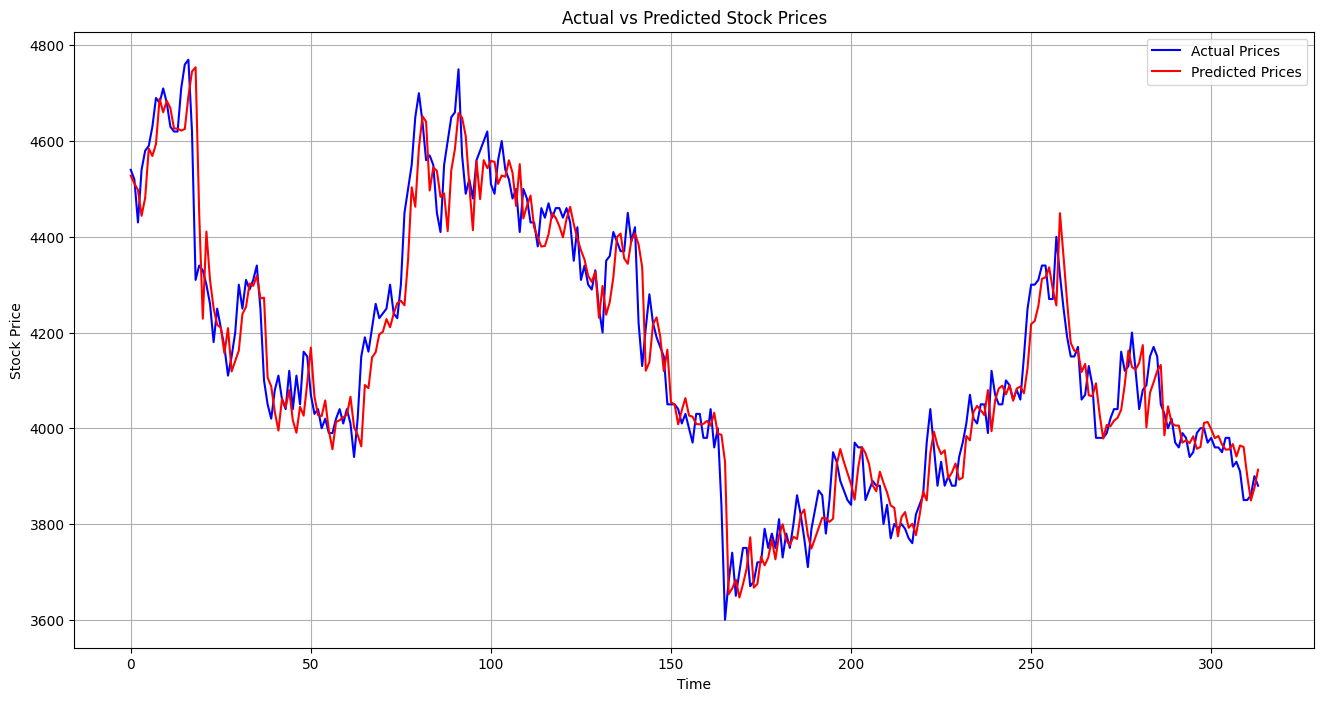

In [ ]:
plt.figure(figsize=(16,8))
plt.plot(y_val_rescaled, label="Actual Prices", color='blue', linestyle='-')
plt.plot(y_val_pred_rescaled, label="Predicted Prices", color='red', linestyle='-')
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.title("Actual vs Predicted Stock Prices")
plt.legend()
plt.grid(True)
plt.show()

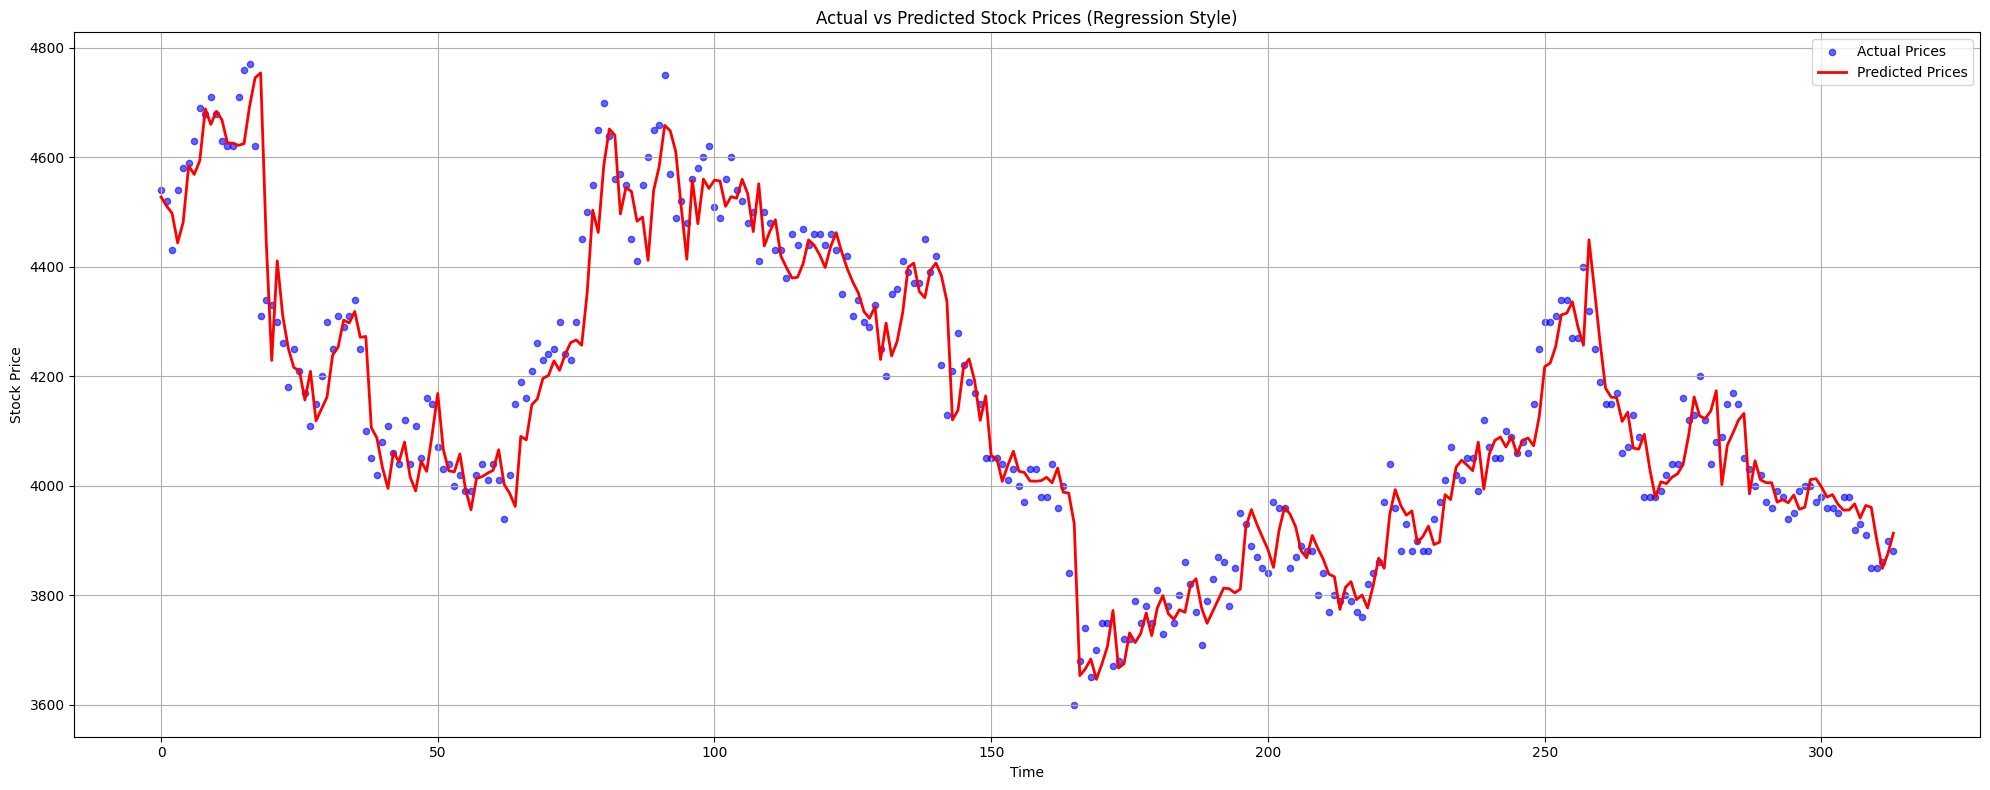

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20,8))

plt.scatter(range(len(y_val_rescaled)), y_val_rescaled, label="Actual Prices", color='blue', alpha=0.6, s=20)

plt.plot(y_val_pred_rescaled, label="Predicted Prices", color='red', linewidth=2)

plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.title("Actual vs Predicted Stock Prices (Regression Style)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
test_loss = final_model.evaluate(X_test_windows, y_test_windows, verbose=0)

y_pred = final_model.predict(X_test_windows)
y_test_rescaled = scaler_y.inverse_transform(y_test_windows.reshape(-1, 1))
y_pred_rescaled = scaler_y.inverse_transform(y_pred.reshape(-1, 1))

rmse = np.sqrt(mean_squared_error(y_test_rescaled, y_pred_rescaled))
mape = mean_absolute_percentage_error(y_test_rescaled, y_pred_rescaled) * 100
r2 = r2_score(y_test_rescaled, y_pred_rescaled)

rmse_de_test = np.sqrt(mean_squared_error(y_test_windows, y_pred))

print("Test Loss (MSE by default):", test_loss)
print("Test RMSE:", rmse)
print("Test MAPE:", mape, "%")
print("Test R-Squared:", r2)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Test Loss (MSE by default): [0.0014898452209308743, 0.02910999394953251, 0.03859851136803627]
Test RMSE: 67.16140204167768
Test MAPE: 1.5922022534312477 %
Test R-Squared: 0.9794321026152051


In [ ]:
print("\nContoh hasil prediksi (rescaled):\n", y_pred_rescaled[:20])
print("\nContoh nilai aktual (rescaled):\n", y_test_rescaled[:20])
pengurangan = y_test_rescaled - y_pred_rescaled
print("\nContoh hasil pengurangan (rescaled):\n", pengurangan[:500])


Contoh hasil prediksi (rescaled):
 [[3769.6628]
 [3748.545 ]
 [3753.3833]
 [3719.435 ]
 [3735.218 ]
 [3716.832 ]
 [3721.8042]
 [3735.5303]
 [3705.3564]
 [3738.3838]
 [3796.7898]
 [3803.5718]
 [3841.0781]
 [3791.8582]
 [3785.0632]
 [3749.3528]
 [3764.9   ]
 [3761.0273]
 [3777.1924]
 [3787.4268]]

Contoh nilai aktual (rescaled):
 [[3760.]
 [3690.]
 [3700.]
 [3710.]
 [3710.]
 [3680.]
 [3720.]
 [3680.]
 [3730.]
 [3810.]
 [3810.]
 [3860.]
 [3770.]
 [3760.]
 [3720.]
 [3750.]
 [3750.]
 [3770.]
 [3780.]
 [3720.]]

Contoh hasil pengurangan (rescaled):
 [[  -9.6628418 ]
 [ -58.54492188]
 [ -53.38330078]
 [  -9.43505859]
 [ -25.21801758]
 [ -36.83203125]
 [  -1.80419922]
 [ -55.53027344]
 [  24.64355469]
 [  71.61621094]
 [  13.21020508]
 [  56.42822266]
 [ -71.078125  ]
 [ -31.8581543 ]
 [ -65.06323242]
 [   0.6472168 ]
 [ -14.89990234]
 [   8.97265625]
 [   2.80761719]
 [ -67.42675781]
 [  -0.23730469]
 [ -44.68237305]
 [  46.87426758]
 [ -28.26123047]
 [  41.54663086]
 [  11.08569336]
 [ -69.

In [ ]:
test_dates = date_array_for_testing[-len(y_test_rescaled):]

df_test_prediksi = pd.DataFrame({
    'date': test_dates[:40],
    'actual': y_test_rescaled[:40].flatten(),
    'prediksi': y_pred_rescaled[:40].flatten()
})

df_test_prediksi['selisih'] = df_test_prediksi['actual'] - df_test_prediksi['prediksi']

df_test_prediksi[['date', 'prediksi']].to_csv('hasil_pred_testing.csv', index=False)

df_test_prediksi[['date', 'actual']].to_csv('data_close_test.csv', index=False)

print("File berhasil disimpan:")
print("- hasil_pred_testing.csv")
print("- data_close_test.csv")


File berhasil disimpan:
- hasil_pred_testing.csv
- data_close_test.csv


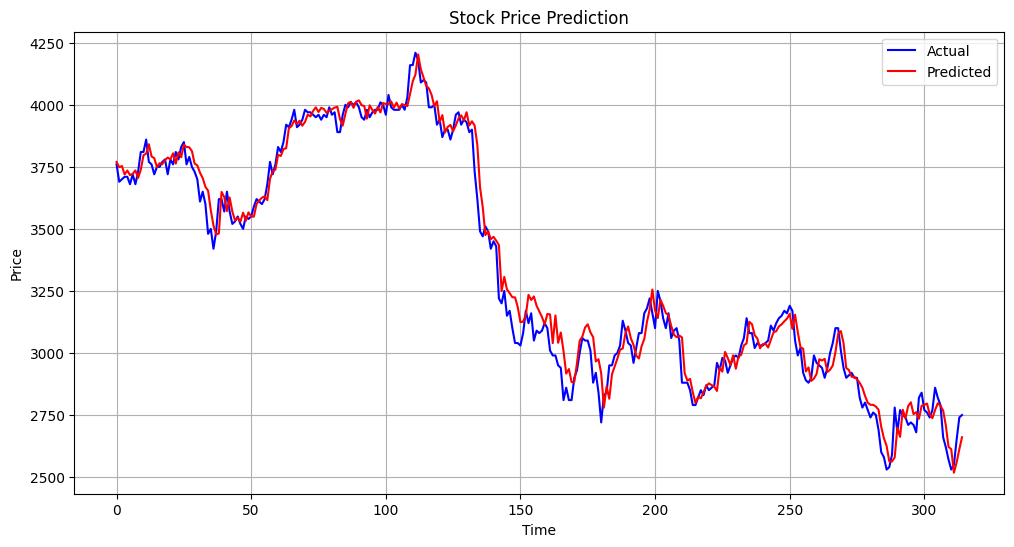

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_rescaled, label='Actual', color='blue')
plt.plot(y_pred_rescaled, label='Predicted', color='red', linestyle='-')
plt.title('Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid()
plt.show()

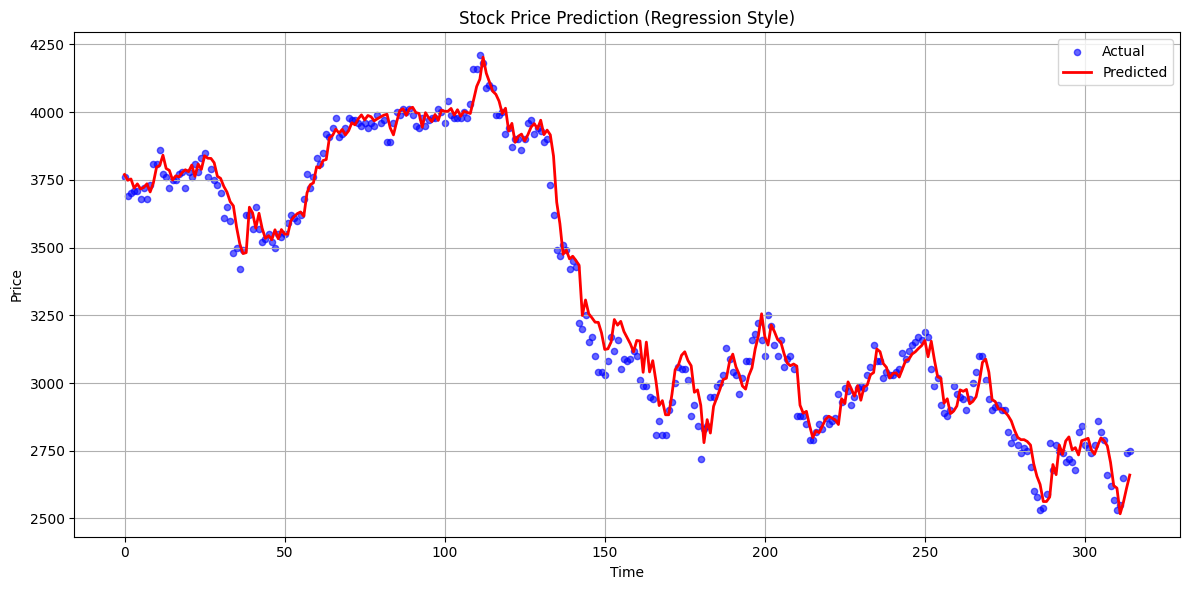

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.scatter(range(len(y_test_rescaled)), y_test_rescaled, label='Actual', color='blue', alpha=0.6, s=20)

plt.plot(y_pred_rescaled, label='Predicted', color='red', linewidth=2)

plt.title('Stock Price Prediction (Regression Style)')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
final_model.save('model_lstm.h5')

Prediksi saham

In [ ]:
import joblib
import numpy as np
import pandas as pd

# ========================================
# Load model dan scaler
# ========================================
model = final_model
scaler_x = joblib.load('scaler_x.pkl')
scaler_y = joblib.load('scaler_y.pkl')

# ========================================
# Load data eksternal dan pastikan kolom tanggal tersedia
# ========================================
external_df = pd.read_csv('/content/data_telkom_input prediksi.csv')

external_df['date'] = pd.to_datetime(external_df['date'])

features = ['open', 'high', 'low', 'volume', 'return', 'volatility', 'ma']
external_features = external_df[features]
valid_dates = external_df['date']

# ========================================
# Scale data eksternal
# ========================================
external_scaled = scaler_x.transform(external_features.values)

# ========================================
# Ambil window terakhir dari data uji
# ========================================

last_window = X_test_windows[-1].copy()

# ========================================
# Fungsi prediksi multi-hari
# ========================================
def predict_future_days(model, last_window, external_scaled, n_days):
    preds_scaled = []
    current_window = last_window.copy()

    for i in range(n_days):

        pred_scaled = model.predict(current_window[np.newaxis, :, :])[0][0]
        preds_scaled.append(pred_scaled)


        if i < len(external_scaled):
            next_input = external_scaled[i]
        else:
            next_input = np.zeros(current_window.shape[1])


        current_window = np.vstack([current_window[1:], next_input])


    preds = scaler_y.inverse_transform(np.array(preds_scaled).reshape(-1, 1)).flatten()
    return preds

# ========================================
# Prediksi dan buat DataFrame hasil
# ========================================
n_days_ahead = len(external_scaled)
future_preds = predict_future_days(model, last_window, external_scaled, n_days=n_days_ahead)

pred_df = pd.DataFrame({
    'Tanggal': valid_dates,
    'Prediksi Close': future_preds
})

print(pred_df)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━

In [ ]:
pred_df.to_csv("Prediksi Telkom.csv")

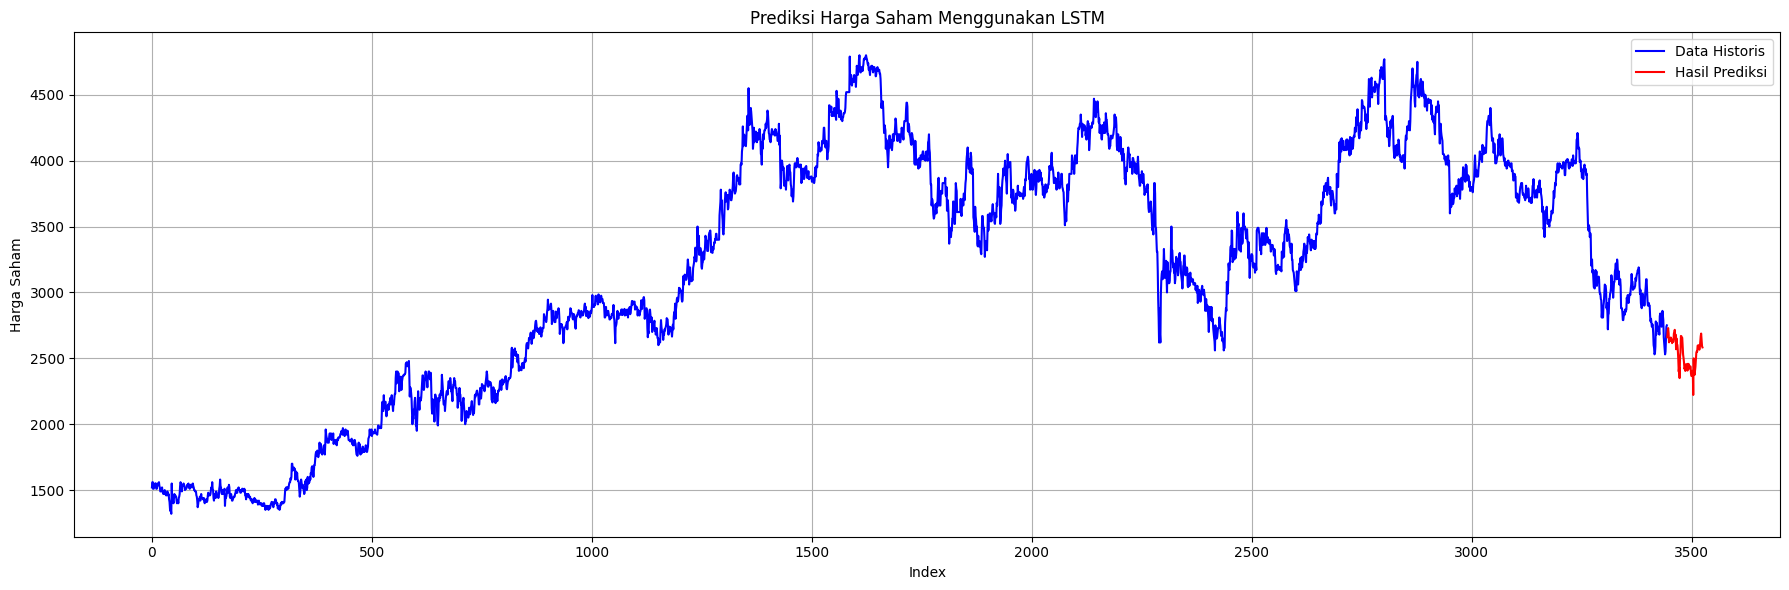

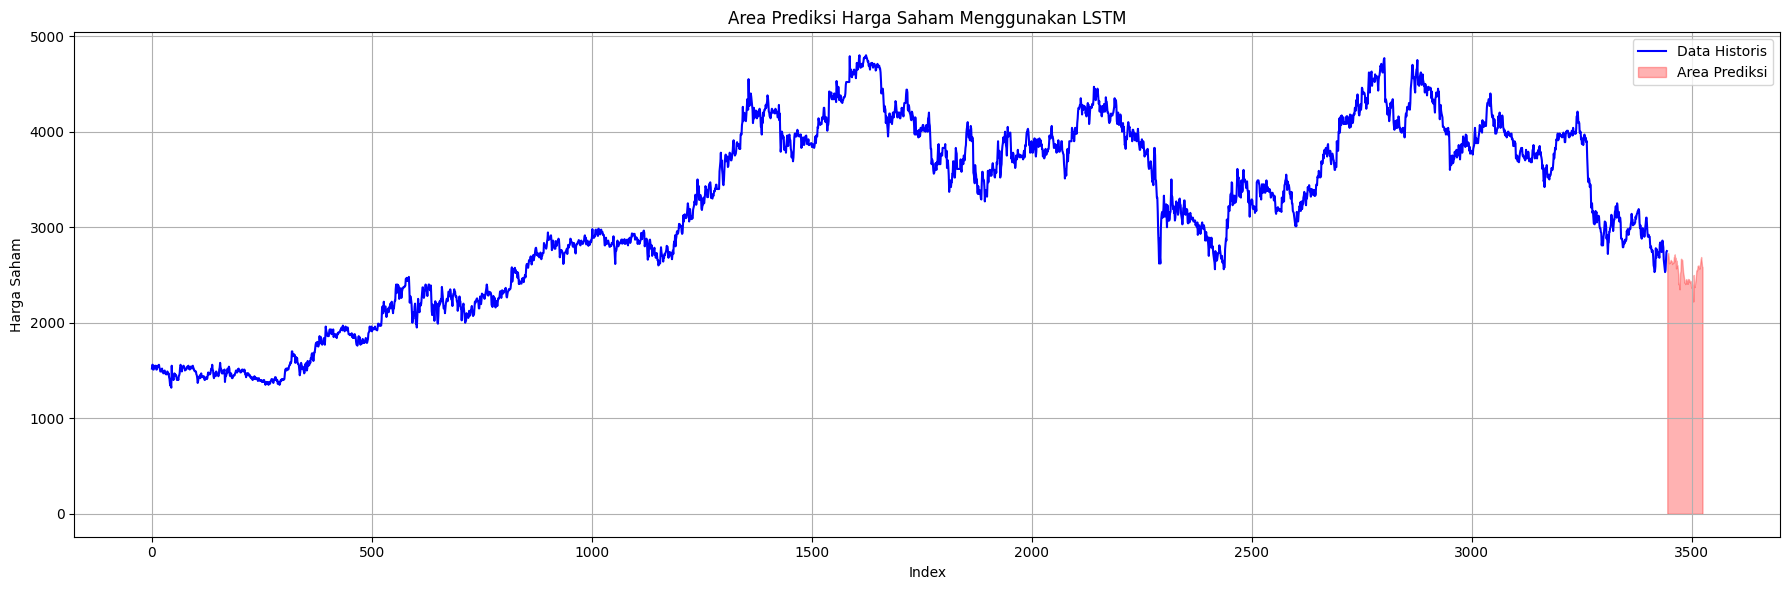

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

historical_df = df_data.copy()
historical_df['Prediksi Close'] = pd.Series([np.nan] * len(historical_df), dtype='float64')
pred_df = pred_df.reset_index(drop=True)
pred_combined = pd.DataFrame({
    'close': pd.Series([np.nan] * len(pred_df), dtype='float64'),
    'Prediksi Close': pred_df['Prediksi Close'].astype('float64')
})
combined_df = pd.concat([historical_df[['close', 'Prediksi Close']], pred_combined], ignore_index=True)

plt.figure(figsize=(18, 6))
plt.plot(combined_df['close'], label='Data Historis', color='blue')
plt.plot(combined_df['Prediksi Close'], label='Hasil Prediksi', color='red')
plt.xlabel('Index')
plt.ylabel('Harga Saham')
plt.title('Prediksi Harga Saham Menggunakan LSTM')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 6))
plt.plot(combined_df['close'], label='Data Historis', color='blue')
plt.fill_between(combined_df.index, combined_df['Prediksi Close'], color='red', alpha=0.3, label='Area Prediksi')
plt.xlabel('Index')
plt.ylabel('Harga Saham')
plt.title('Area Prediksi Harga Saham Menggunakan LSTM')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Analisis VAR

In [ ]:
file_path = '/content/Prediksi Telkom.csv'
data_pred = pd.read_csv(file_path, index_col=0)

file_path = '/content/data_asli_telkom_close.csv'
data_real = pd.read_csv(file_path)

In [ ]:
data_pred.head()

,Tanggal,Prediksi Close
0,2025-01-02,2660.3030
1,2025-01-03,2713.7385
2,2025-01-06,2729.4102
3,2025-01-07,2691.1707
4,2025-01-08,2621.3318


In [ ]:
data_real['date'] = pd.to_datetime(data_real['date'])
pred_df['Tanggal'] = pd.to_datetime(pred_df['Tanggal'])

merged_df = pd.merge(pred_df, data_real[['date', 'close']], left_on='Tanggal', right_on='date', how='inner')

rmse = np.sqrt(mean_squared_error(merged_df['close'], merged_df['Prediksi Close']))
mape = mean_absolute_percentage_error(merged_df['close'], merged_df['Prediksi Close']) * 100
r2 = r2_score(merged_df['close'], merged_df['Prediksi Close'])

print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.2f}%")
print(f"R-Squared: {r2:.4f}")

RMSE: 67.4222
MAPE: 2.10%
R-Squared: 0.7087


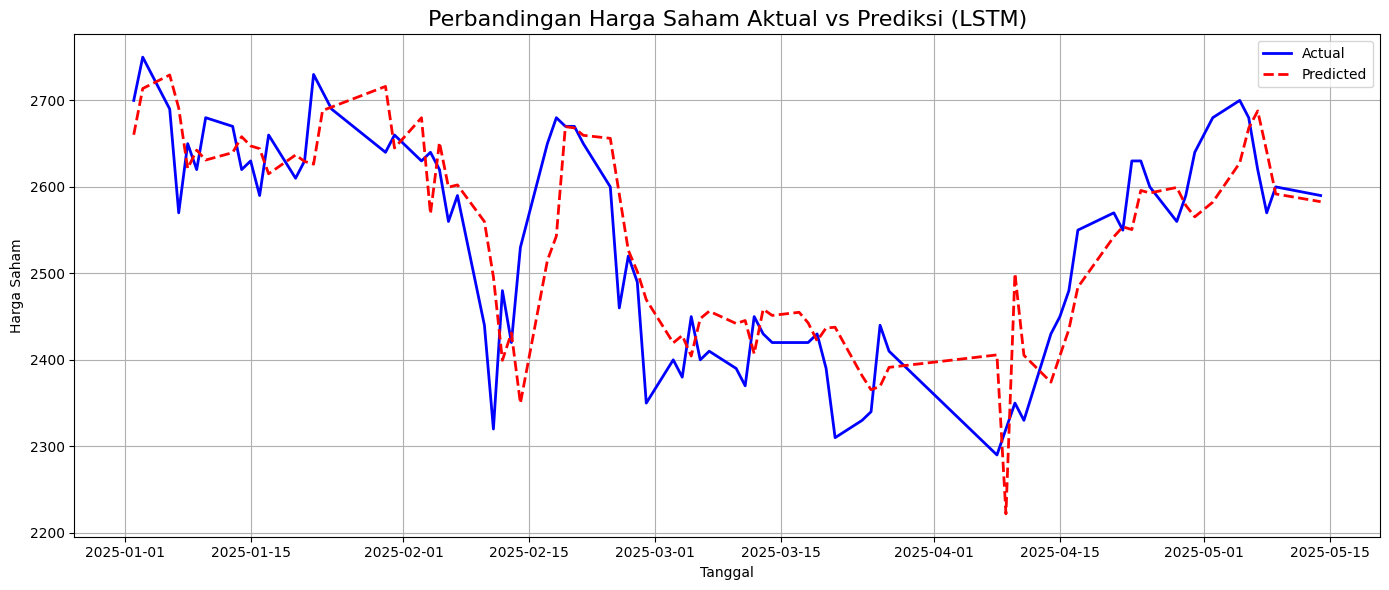

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(merged_df['Tanggal'], merged_df['close'], label='Actual', color='blue', linewidth=2)
plt.plot(merged_df['Tanggal'], merged_df['Prediksi Close'], label='Predicted', color='red', linestyle='--', linewidth=2)
plt.title('Perbandingan Harga Saham Aktual vs Prediksi (LSTM)', fontsize=16)
plt.xlabel('Tanggal')
plt.ylabel('Harga Saham')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

VAR menggunakan data prediksi

In [ ]:
data_pred['Return'] = data_pred['Prediksi Close'].pct_change()
returns = data_pred['Return'].dropna()

In [ ]:
avg_return = returns.mean()
std_dev = returns.std()
days = len(returns)  # Jumlah hari pada periode data

In [ ]:
simulations = 10000
initial_investment = 1_000_000
confidence_level = 0.95
z_score = 1.65

In [ ]:
# === MONTE CARLO SIMULASI UNTUK 1 HARI ===
np.random.seed(42)
simulated_returns_1d = np.random.normal(avg_return, std_dev, simulations)

sim_mean_1d = simulated_returns_1d.mean()
sim_std_1d = simulated_returns_1d.std()
VaR_percent_1d = sim_mean_1d - z_score * sim_std_1d
VaR_value_1d = initial_investment * VaR_percent_1d

print(f"\n[VaR Monte Carlo - 1 Hari] Confidence {int(confidence_level * 100)}%:")
print(f"VaR (%): {VaR_percent_1d:.2%}")
print(f"VaR (Rp): Rp {VaR_value_1d:,.0f}")

print("=========================================")
print("Simulasi Risiko Kerugian Maksimum (VaR) Selama 1 Hari – Confidence Level 95%")
print(f"VaR (%): {abs(VaR_percent_1d):.2%}")
print(f"VaR (Rp): Rp {abs(VaR_value_1d):,.0f}")


[VaR Monte Carlo - 1 Hari] Confidence 95%:
VaR (%): -4.07%
VaR (Rp): Rp -40,750
Simulasi Risiko Kerugian Maksimum (VaR) Selama 1 Hari – Confidence Level 95%
VaR (%): 4.07%
VaR (Rp): Rp 40,750


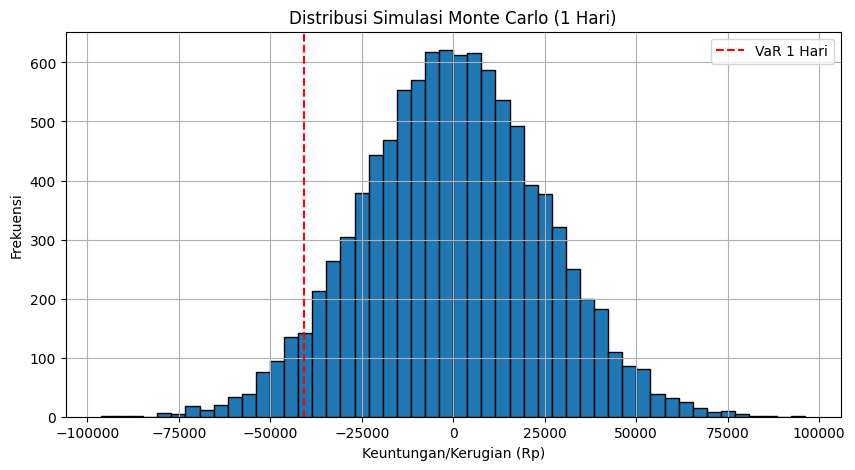

In [ ]:
plt.figure(figsize=(10,5))
plt.hist(simulated_returns_1d * initial_investment, bins=50, edgecolor='black')
plt.axvline(VaR_value_1d, color='red', linestyle='--', label='VaR 1 Hari')
plt.title('Distribusi Simulasi Monte Carlo (1 Hari)')
plt.xlabel('Keuntungan/Kerugian (Rp)')
plt.ylabel('Frekuensi')
plt.legend()
plt.grid(True)
plt.show()


[VaR Monte Carlo - Total 80 Hari] Confidence 95%:
VaR (%): -36.57%
VaR (Rp): Rp -365,718
Simulasi Risiko Kerugian Maksimum (VaR) Selama 80 Hari – Confidence Level 95%
VaR (%): 36.57%
VaR (Rp): Rp 365,718


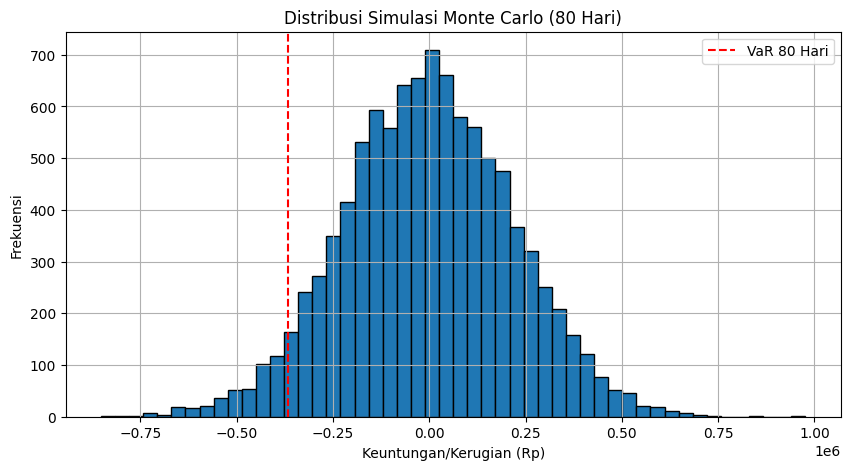

In [ ]:
avg_return_total = avg_return * days
std_dev_total = std_dev * np.sqrt(days)

simulated_returns_total = np.random.normal(avg_return_total, std_dev_total, simulations)
sim_mean_total = simulated_returns_total.mean()
sim_std_total = simulated_returns_total.std()

VaR_percent_total = sim_mean_total - z_score * sim_std_total
VaR_value_total = initial_investment * VaR_percent_total

print(f"\n[VaR Monte Carlo - Total {days} Hari] Confidence {int(confidence_level * 100)}%:")
print(f"VaR (%): {VaR_percent_total:.2%}")
print(f"VaR (Rp): Rp {VaR_value_total:,.0f}")


print("=========================================")
print("Simulasi Risiko Kerugian Maksimum (VaR) Selama 80 Hari – Confidence Level 95%")
print(f"VaR (%): {abs(VaR_percent_total):.2%}")
print(f"VaR (Rp): Rp {abs(VaR_value_total):,.0f}")

plt.figure(figsize=(10,5))
plt.hist(simulated_returns_total * initial_investment, bins=50, edgecolor='black')
plt.axvline(VaR_value_total, color='red', linestyle='--', label=f'VaR {days} Hari')
plt.title(f'Distribusi Simulasi Monte Carlo ({days} Hari)')
plt.xlabel('Keuntungan/Kerugian (Rp)')
plt.ylabel('Frekuensi')
plt.legend()
plt.grid(True)
plt.show()

VAR menggunakan data real

In [ ]:
# === 2. HITUNG RETURN HARIAN ===
data_real['Return'] = data_real['close'].pct_change()
returns = data_real['Return'].dropna()

In [ ]:
avg_return = returns.mean()
std_dev = returns.std()
days = len(returns)

simulations = 10000
initial_investment = 1_000_000
confidence_level = 0.95
z_score = 1.65

In [ ]:
np.random.seed(42)
simulated_returns_1d = np.random.normal(avg_return, std_dev, simulations)

sim_mean_1d = simulated_returns_1d.mean()
sim_std_1d = simulated_returns_1d.std()
VaR_percent_1d = sim_mean_1d - z_score * sim_std_1d
VaR_value_1d = initial_investment * VaR_percent_1d

print(f"\n[VaR Monte Carlo - 1 Hari] Confidence {int(confidence_level * 100)}%:")
print(f"VaR (%): {VaR_percent_1d:.2%}")
print(f"VaR (Rp): Rp {VaR_value_1d:,.0f}")


print("=========================================")
print("Simulasi Risiko Kerugian Maksimum (VaR) Selama 1 Hari – Confidence Level 95%")
print(f"VaR (%): {abs(VaR_percent_1d):.2%}")
print(f"VaR (Rp): Rp {abs(VaR_value_1d):,.0f}")


[VaR Monte Carlo - 1 Hari] Confidence 95%:
VaR (%): -4.09%
VaR (Rp): Rp -40,884
Simulasi Risiko Kerugian Maksimum (VaR) Selama 1 Hari – Confidence Level 95%
VaR (%): 4.09%
VaR (Rp): Rp 40,884


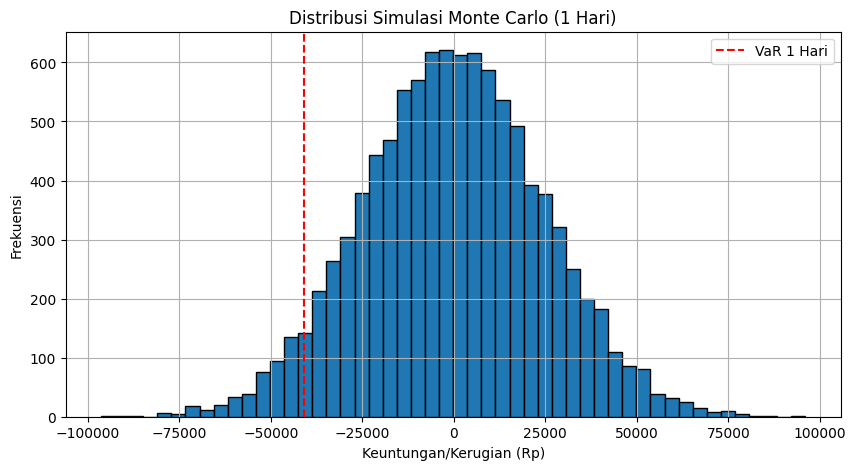

In [ ]:
plt.figure(figsize=(10,5))
plt.hist(simulated_returns_1d * initial_investment, bins=50, edgecolor='black')
plt.axvline(VaR_value_1d, color='red', linestyle='--', label='VaR 1 Hari')
plt.title('Distribusi Simulasi Monte Carlo (1 Hari)')
plt.xlabel('Keuntungan/Kerugian (Rp)')
plt.ylabel('Frekuensi')
plt.legend()
plt.grid(True)
plt.show()


[VaR Monte Carlo - Total 80 Hari] Confidence 95%:
VaR (%): -37.72%
VaR (Rp): Rp -377,155
Simulasi Risiko Kerugian Maksimum (VaR) Selama 80 Hari – Confidence Level 95%
VaR (%): 37.72%
VaR (Rp): Rp 377,155


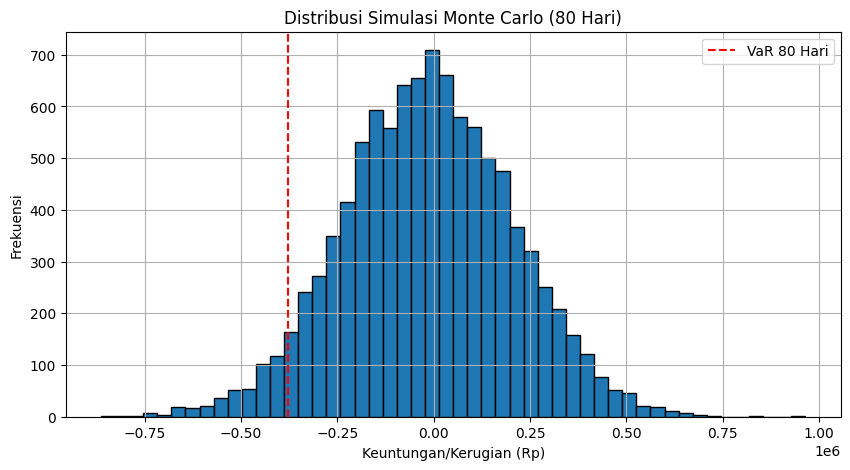

In [ ]:
avg_return_total = avg_return * days
std_dev_total = std_dev * np.sqrt(days)

simulated_returns_total = np.random.normal(avg_return_total, std_dev_total, simulations)
sim_mean_total = simulated_returns_total.mean()
sim_std_total = simulated_returns_total.std()

VaR_percent_total = sim_mean_total - z_score * sim_std_total
VaR_value_total = initial_investment * VaR_percent_total

print(f"\n[VaR Monte Carlo - Total {days} Hari] Confidence {int(confidence_level * 100)}%:")
print(f"VaR (%): {VaR_percent_total:.2%}")
print(f"VaR (Rp): Rp {VaR_value_total:,.0f}")

print("=========================================")
print("Simulasi Risiko Kerugian Maksimum (VaR) Selama 80 Hari – Confidence Level 95%")
print(f"VaR (%): {abs(VaR_percent_total):.2%}")
print(f"VaR (Rp): Rp {abs(VaR_value_total):,.0f}")

plt.figure(figsize=(10,5))
plt.hist(simulated_returns_total * initial_investment, bins=50, edgecolor='black')
plt.axvline(VaR_value_total, color='red', linestyle='--', label=f'VaR {days} Hari')
plt.title(f'Distribusi Simulasi Monte Carlo ({days} Hari)')
plt.xlabel('Keuntungan/Kerugian (Rp)')
plt.ylabel('Frekuensi')
plt.legend()
plt.grid(True)
plt.show()